In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/aqi2.csv')
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00,16.554731,80.649110,SO2,20.0,23.0,21.0
1,India,Andhra_Pradesh,Vijayawada,"Rajiv Nagar, Vijayawada - APPCB",19-05-2025 10:00,16.554731,80.649110,OZONE,17.0,35.0,22.0
2,India,Andhra_Pradesh,Visakhapatnam,"GVM Corporation, Visakhapatnam - APPCB",19-05-2025 10:00,17.720000,83.300000,PM10,23.0,66.0,36.0
3,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00,27.103358,93.679645,NO2,4.0,5.0,5.0
4,India,Arunachal_Pradesh,Naharlagun,"Naharlagun, Naharlagun - APSPCB",19-05-2025 10:00,27.103358,93.679645,CO,10.0,19.0,12.0


In [ ]:
df.shape

(3077, 11)

In [ ]:
df = df.drop(columns=['country'])

In [ ]:
df = df.drop(columns=['last_update'])

In [ ]:
df = df.drop(columns=['pollutant_min', 'pollutant_max'])

In [ ]:
df = df.drop(columns=['station'])

In [ ]:
df.head()

,state,city,latitude,longitude,pollutant_id,pollutant_avg
0,Andhra_Pradesh,Vijayawada,16.554731,80.649110,SO2,21.0
1,Andhra_Pradesh,Vijayawada,16.554731,80.649110,OZONE,22.0
2,Andhra_Pradesh,Visakhapatnam,17.720000,83.300000,PM10,36.0
3,Arunachal_Pradesh,Naharlagun,27.103358,93.679645,NO2,5.0
4,Arunachal_Pradesh,Naharlagun,27.103358,93.679645,CO,12.0


In [ ]:
df.shape

(3077, 6)

In [ ]:
df_pivot = df.pivot_table(
    index='city',
    columns='pollutant_id',
    values='pollutant_avg'
).reset_index()

df_pivot.head()

pollutant_id,city,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,Agartala,2.000000,NaN,NaN,127.000000,NaN,NaN,NaN
1,Agra,23.833333,3.200000,26.333333,25.500000,97.833333,66.80,20.166667
2,Ahmedabad,20.375000,4.857143,37.777778,12.222222,72.000000,63.75,12.000000
3,Ahmednagar,31.000000,13.000000,28.000000,6.000000,NaN,11.00,10.000000
4,Aizawl,3.000000,NaN,NaN,1.000000,NaN,NaN,2.000000


In [ ]:
df_pivot.isnull().sum()

,0
pollutant_id,
city,0
CO,13
NH3,36
NO2,23
OZONE,12
PM10,28
PM2.5,28
SO2,19


In [ ]:
# Step 1: Remove rows where target is missing
df_pivot = df_pivot.dropna(subset=['PM2.5'])

# Step 2: Drop NH3 (optional but recommended)
df_pivot = df_pivot.drop(columns=['NH3'])

# Step 3: Fill remaining missing values
df_pivot = df_pivot.fillna(df_pivot.mean(numeric_only=True))

In [ ]:
df_pivot.isnull().sum()

,0
pollutant_id,
city,0
CO,0
NO2,0
OZONE,0
PM10,0
PM2.5,0
SO2,0


In [ ]:
df_analysis = df_pivot.copy()

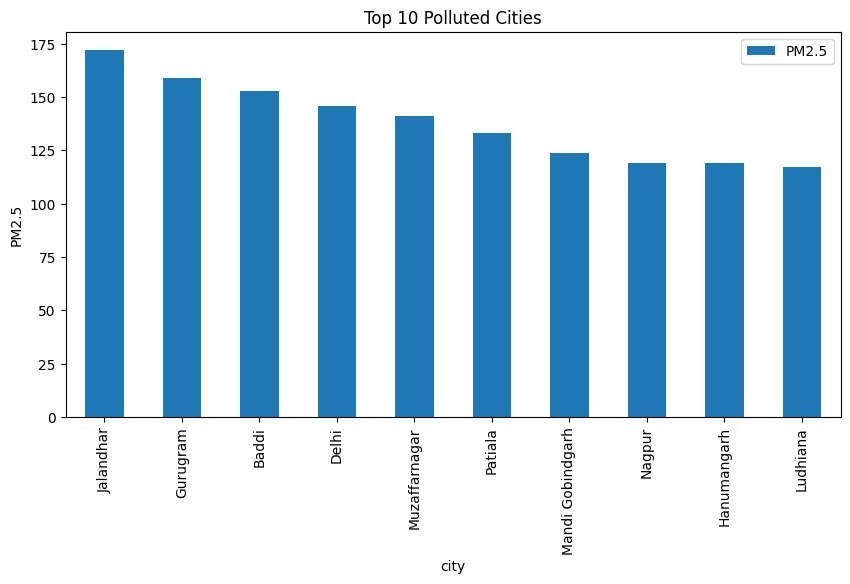

In [ ]:
df_analysis.sort_values(by='PM2.5', ascending=False).head(10).plot(
    x='city', y='PM2.5', kind='bar', figsize=(10,5)
)
plt.title("Top 10 Polluted Cities")
plt.ylabel("PM2.5")
plt.show()

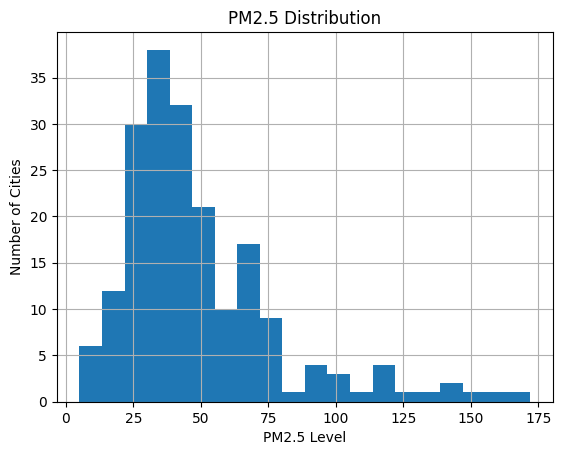

In [ ]:
df_analysis['PM2.5'].hist(bins=20)
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5 Level")
plt.ylabel("Number of Cities")
plt.show()

In [ ]:
df_model = df_pivot.drop(columns=['city'], errors='ignore')

In [ ]:
X = df_model[['CO', 'NO2', 'SO2', 'PM10', 'OZONE']]
y = df_model['PM2.5']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

MAE: 15.663218752532593
RMSE: 20.496779938954035


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)

MAE: 17.708791208791208
RMSE: 25.78124674791678


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

MAE: 16.66583239410162
RMSE: 22.58399430670386


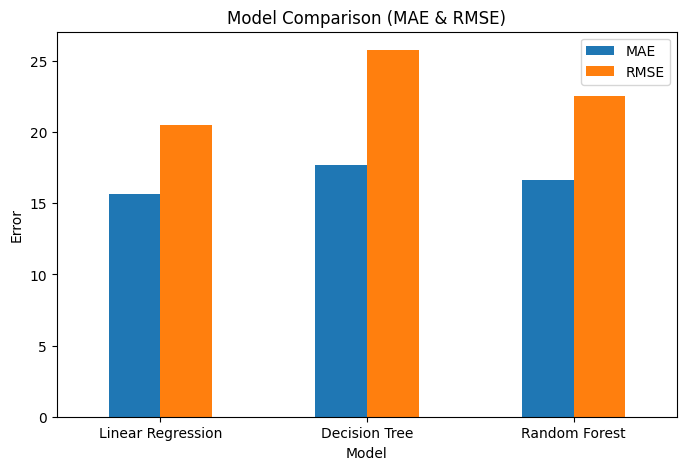

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf]
})

results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison (MAE & RMSE)")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

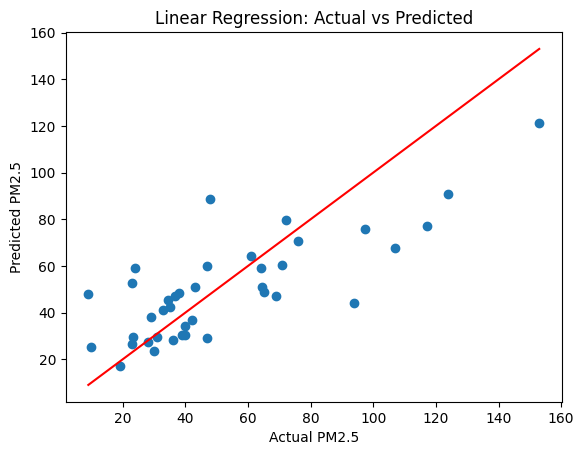

In [ ]:
plt.scatter(y_test, y_pred_lr)

# Red perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

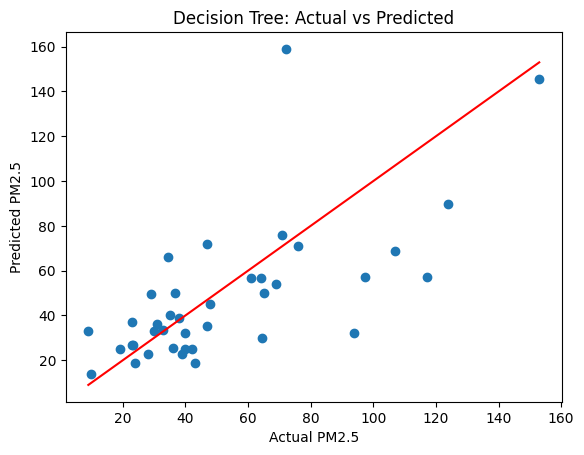

In [ ]:
plt.scatter(y_test, y_pred_dt)

# Red perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

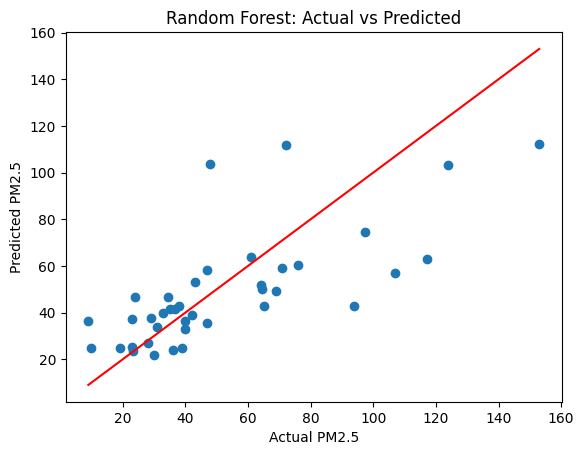

In [ ]:
plt.scatter(y_test, y_pred_rf)

# Red perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Random Forest: Actual vs Predicted")
plt.show()